# Visualizing High-Dimensional Data: PCA and t-SNE

This notebook uses scikit-learn's handwritten digits dataset to compare PCA and t-SNE for dimensionality reduction, visualization, and simple classification. The analysis is reproducible because random seeds are fixed where algorithms are stochastic.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110

Samples: 1,797
Features per sample: 64
Image shape: (8, 8)
Labels: [0 1 2 3 4 5 6 7 8 9]


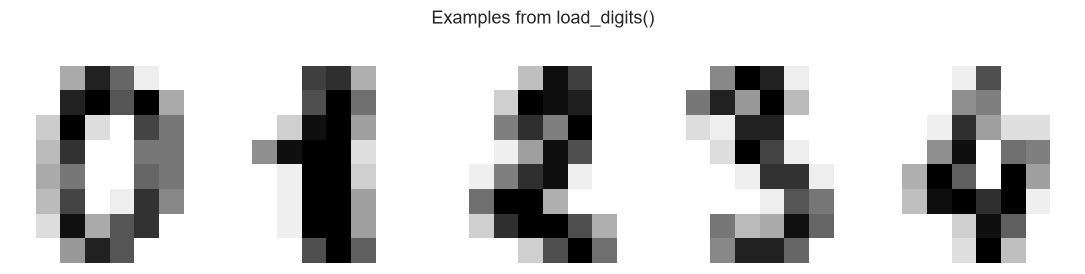

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print(f'Samples: {X.shape[0]:,}')
print(f'Features per sample: {X.shape[1]}')
print(f'Image shape: {digits.images.shape[1:]}')
print(f'Labels: {np.unique(y)}')

fig, axes = plt.subplots(1, 5, figsize=(10, 2.4))
for digit, ax in zip(digits.images[:5], axes):
    ax.imshow(digit, cmap='gray_r')
    ax.axis('off')
fig.suptitle('Examples from load_digits()', y=1.02)
plt.tight_layout()
plt.show()

## 2. PCA: Principal Component Analysis



Components needed for at least 90% variance: 31
Variance explained by those components: 0.900


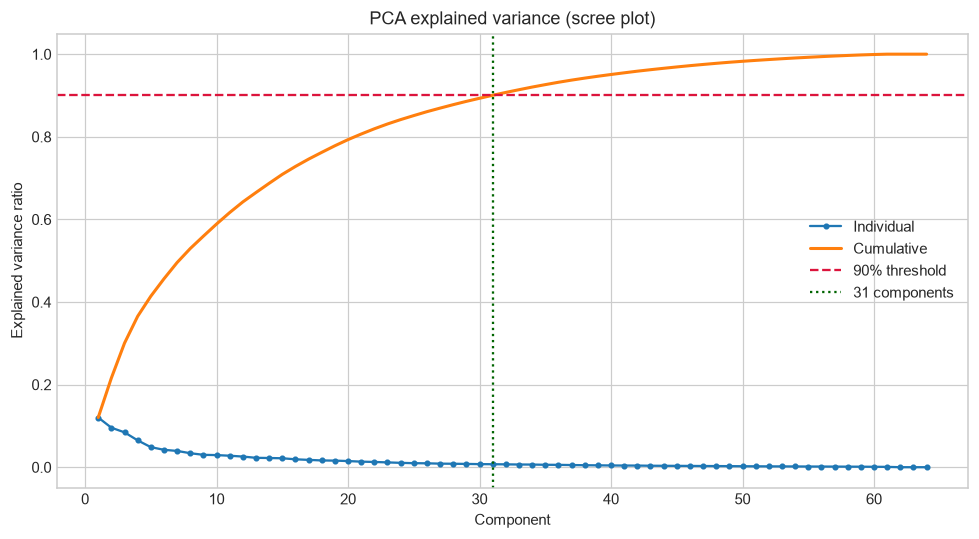

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.90) + 1)
print(f'Components needed for at least 90% variance: {n_components_90}')
print(f'Variance explained by those components: {cumvar[n_components_90 - 1]:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
components = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
ax.plot(components, pca_full.explained_variance_ratio_, marker='.', label='Individual')
ax.plot(components, cumvar, linewidth=2, label='Cumulative')
ax.axhline(0.90, color='crimson', linestyle='--', label='90% threshold')
ax.axvline(n_components_90, color='darkgreen', linestyle=':', label=f'{n_components_90} components')
ax.set(title='PCA explained variance (scree plot)', xlabel='Component', ylabel='Explained variance ratio')
ax.legend()
plt.tight_layout()
plt.show()

### PCA in two dimensions

PCA is linear: it projects every image onto two directions that retain as much global variance as possible. Some digit groups form recognizable regions, but several classes overlap. This is expected because the directions of greatest overall variation are not necessarily the directions that best separate labels.

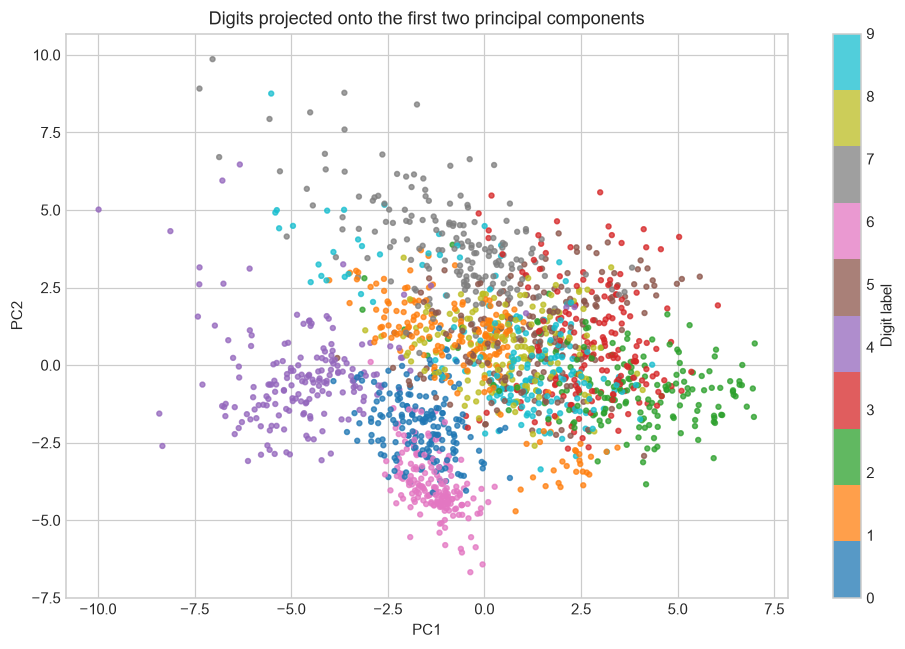

PC1 + PC2 explain 21.6% of standardized variance.


In [4]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='tab10', s=10, alpha=0.75)
ax.set(title='Digits projected onto the first two principal components', xlabel='PC1', ylabel='PC2')
fig.colorbar(scatter, ax=ax, ticks=range(10), label='Digit label')
plt.tight_layout()
plt.show()

print(f'PC1 + PC2 explain {pca_2.explained_variance_ratio_.sum():.1%} of standardized variance.')

### PCA in three dimensions and interpretation

A principal component is a weighted combination of the original 64 pixels. 

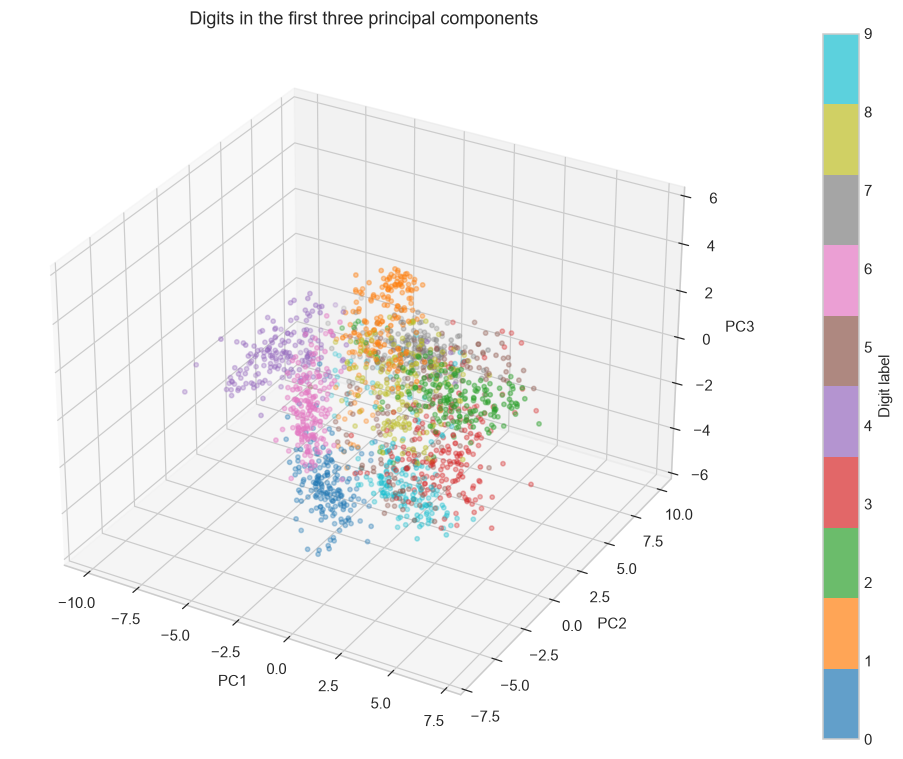

In [5]:
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=y, cmap='tab10', s=8, alpha=0.7)
ax.set(title='Digits in the first three principal components', xlabel='PC1', ylabel='PC2', zlabel='PC3')
fig.colorbar(scatter, ax=ax, pad=0.1, ticks=range(10), label='Digit label')
plt.tight_layout()
plt.show()

## 3. t-SNE: Local Structure for Visualization

t-SNE preserves neighborhoods by converting pairwise similarities into probabilities and optimizing a low-dimensional arrangement with similar local neighborhoods. 

C:\Users\Hrujuta\AppData\Local\Temp\ipykernel_21320\460671941.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


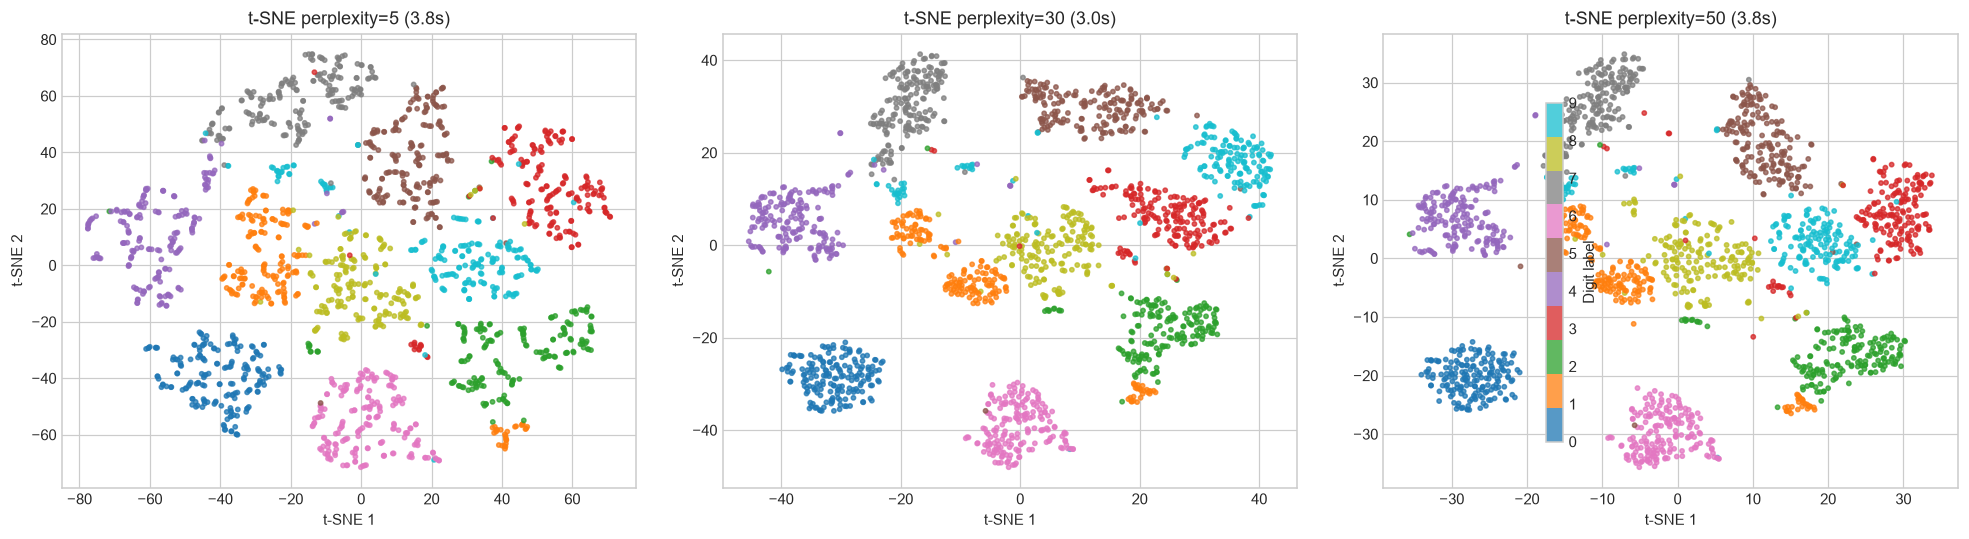

In [6]:
def run_tsne(perplexity):
    start = time.perf_counter()
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init='pca',
        learning_rate='auto',
        max_iter=750,
        random_state=RANDOM_STATE,
    ).fit_transform(X_scaled)
    return embedding, time.perf_counter() - start

tsne_results = {}
for perplexity in (5, 30, 50):
    tsne_results[perplexity] = run_tsne(perplexity)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, perplexity in zip(axes, (5, 30, 50)):
    embedding, elapsed = tsne_results[perplexity]
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
    ax.set(title=f't-SNE perplexity={perplexity} ({elapsed:.1f}s)', xlabel='t-SNE 1', ylabel='t-SNE 2')
fig.colorbar(scatter, ax=axes.ravel().tolist(), ticks=range(10), label='Digit label', shrink=0.8)
plt.tight_layout()
plt.show()

### PCA versus t-SNE visual comparison



C:\Users\Hrujuta\AppData\Local\Temp\ipykernel_21320\1778329948.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


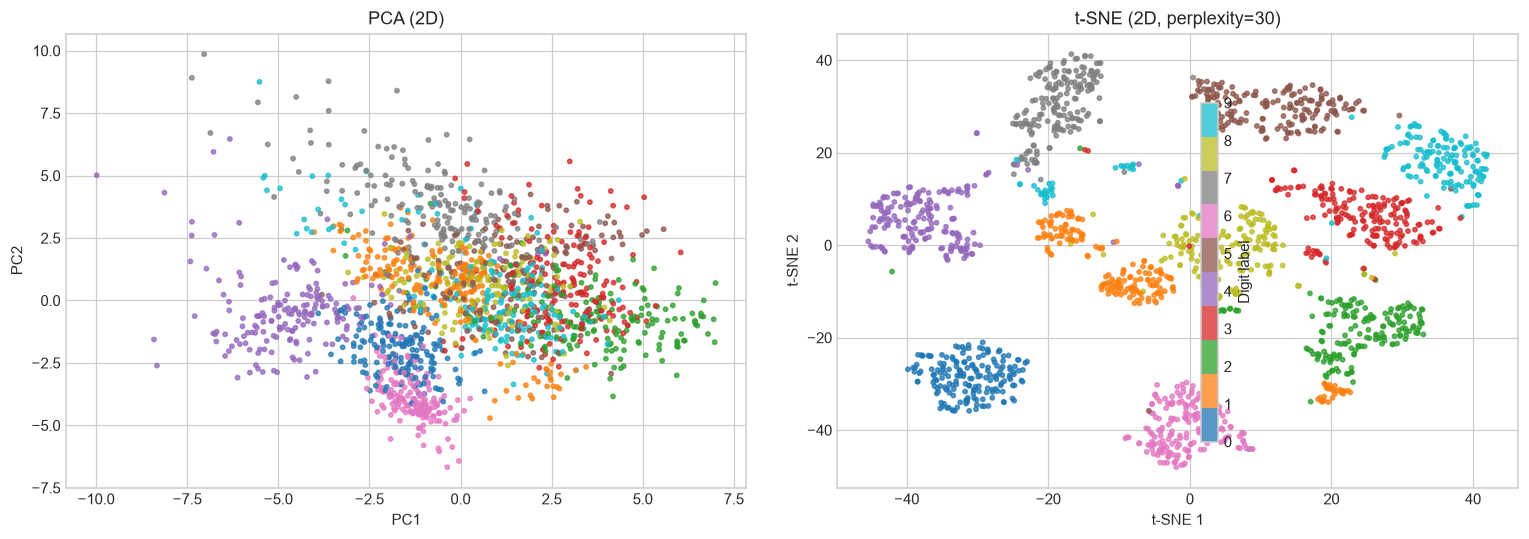

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pca_scatter = axes[0].scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
axes[0].set(title='PCA (2D)', xlabel='PC1', ylabel='PC2')
tsne_scatter = axes[1].scatter(tsne_results[30][0][:, 0], tsne_results[30][0][:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
axes[1].set(title='t-SNE (2D, perplexity=30)', xlabel='t-SNE 1', ylabel='t-SNE 2')
fig.colorbar(tsne_scatter, ax=axes, ticks=range(10), label='Digit label', shrink=0.8)
plt.tight_layout()
plt.show()

## 4. PCA versus t-SNE for Classification



In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

representations = {'Raw 64D': (X_train, X_test)}
for n_components in (2, 10, 30):
    pca_pipeline = Pipeline([
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=RANDOM_STATE)),
    ])
    X_train_reduced = pca_pipeline.fit_transform(X_train)
    X_test_reduced = pca_pipeline.transform(X_test)
    representations[f'PCA {n_components}D'] = (X_train_reduced, X_test_reduced)

# This is intentionally transductive: it illustrates why t-SNE is unsuitable as a
# reusable transform in a normal train/test or production pipeline.
tsne_embedding = tsne_results[30][0]
train_indices, test_indices = train_test_split(np.arange(len(y)), test_size=0.25, stratify=y, random_state=RANDOM_STATE)
representations['t-SNE 2D (transductive)'] = (tsne_embedding[train_indices], tsne_embedding[test_indices])

comparison_rows = []
for name, (X_rep_train, X_rep_test) in representations.items():
    start = time.perf_counter()
    classifier = KNeighborsClassifier(n_neighbors=5)
    classifier.fit(X_rep_train, y_train)
    predictions = classifier.predict(X_rep_test)
    elapsed = time.perf_counter() - start
    comparison_rows.append({
        'Representation': name,
        'Dimensions': X_rep_train.shape[1],
        'Accuracy': accuracy_score(y_test, predictions),
        'k-NN fit + predict seconds': elapsed,
    })

comparison = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False)
display(comparison.style.format({'Accuracy': '{:.3f}', 'k-NN fit + predict seconds': '{:.4f}'}))

,Representation,Dimensions,Accuracy,k-NN fit + predict seconds
0,Raw 64D,64,0.984,0.0189
4,t-SNE 2D (transductive),2,0.967,0.0052
3,PCA 30D,30,0.962,0.0187
2,PCA 10D,10,0.929,0.0105
1,PCA 2D,2,0.542,0.0063


In [9]:
telco_path = Path('WA_Fn-UseC_-Telco-Customer-Churn.csv')
if telco_path.exists():
    telco = pd.read_csv(telco_path)
    telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
    telco = telco.dropna(subset=['TotalCharges'])
    y_telco = (telco.pop('Churn') == 'Yes').astype(int)
    telco = telco.drop(columns=['customerID'])
    X_telco = pd.get_dummies(telco, drop_first=True, dtype=float)
    X_telco = X_telco.fillna(X_telco.median(numeric_only=True))
    X_telco_train, X_telco_test, y_telco_train, y_telco_test = train_test_split(
        X_telco, y_telco, test_size=0.25, stratify=y_telco, random_state=RANDOM_STATE
    )
    telco_results = []
    for name, n_components in [('All encoded features', None), ('PCA 10D', 10), ('PCA 30D', 30)]:
        steps = [('scale', StandardScaler())]
        if n_components is not None:
            steps.append(('pca', PCA(n_components=n_components, random_state=RANDOM_STATE)))
        steps.append(('model', __import__('sklearn.linear_model', fromlist=['LogisticRegression']).LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)))
        model = Pipeline(steps)
        start = time.perf_counter()
        model.fit(X_telco_train, y_telco_train)
        score = model.score(X_telco_test, y_telco_test)
        telco_results.append({'Representation': name, 'Accuracy': score, 'Runtime seconds': time.perf_counter() - start})
    print(f'Telco rows after cleaning: {len(telco):,}; encoded features: {X_telco.shape[1]}')
    display(pd.DataFrame(telco_results).style.format({'Accuracy': '{:.3f}', 'Runtime seconds': '{:.4f}'}))
else:
    print(f'Optional file not found: {telco_path.resolve()}')

Telco rows after cleaning: 7,032; encoded features: 30


,Representation,Accuracy,Runtime seconds
0,All encoded features,0.808,0.0301
1,PCA 10D,0.795,0.0225
2,PCA 30D,0.808,0.0297
